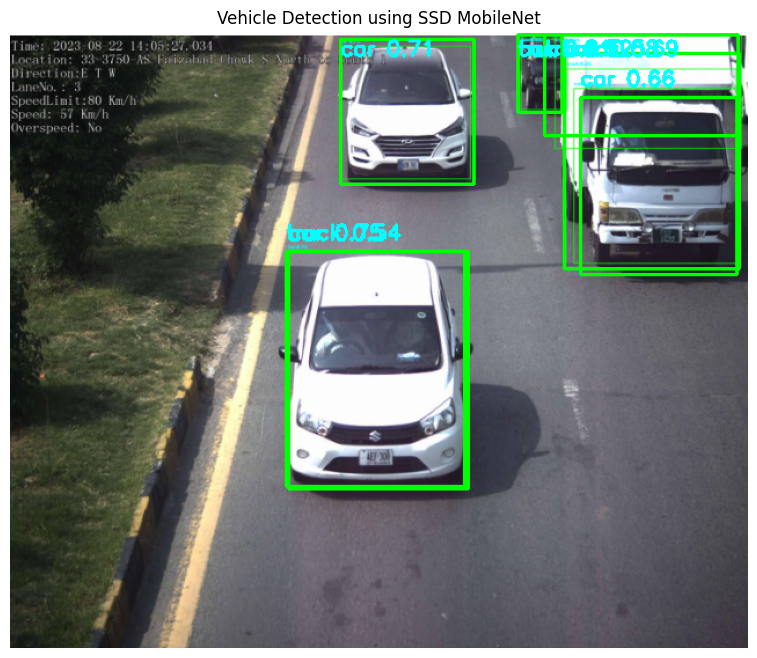

In [8]:
# PROGRAM 5: Write a program using OpenCV to detect vehicles in a road image and draw bounding boxes 
#around the detected vehicles. 
#Vehicle Detection – OpenCV DNN with SSD MobileNet

import cv2
import numpy as np
import matplotlib.pyplot as plt

CONFIG = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
WEIGHTS = "frozen_inference_graph.pb"

net = cv2.dnn_DetectionModel(WEIGHTS, CONFIG)

net.setInputSize(320, 320)
net.setInputScale(1.0 / 127.5)
net.setInputMean((127.5, 127.5, 127.5))
net.setInputSwapRB(True)

classNames = [
    "background","person","bicycle","car","motorcycle","airplane","bus",
    "train","truck","boat","traffic light","fire hydrant","stop sign",
    "parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag",
    "tie","suitcase","frisbee","skis","snowboard","sports ball","kite",
    "baseball bat","baseball glove","skateboard","surfboard","tennis racket",
    "bottle","wine glass","cup","fork","knife","spoon","bowl","banana",
    "apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","dining table",
    "toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock",
    "vase","scissors","teddy bear","hair drier","toothbrush"
]

image = cv2.imread("vehicle.png")

if image is None:
    raise FileNotFoundError("vehicle.png not found")

output = image.copy()

classIds, scores, boxes = net.detect(
    image,
    confThreshold=0.45,
    nmsThreshold=0.40
)

classIds = np.array(classIds).flatten()
scores = np.array(scores).flatten()

vehicle_names = {"car", "motorcycle", "bus", "truck"}

for classId, score, box in zip(classIds, scores, boxes):

    classId = int(classId)

    # Safety check
    if classId >= len(classNames):
        continue

    name = classNames[classId]

    if name in vehicle_names:

        x, y, w, h = box

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            output,
            f"{name} {score:.2f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 0),
            2
        )

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title("Vehicle Detection using SSD MobileNet")
plt.axis("off")
plt.show()